# Week 6 Final: Baseline Models and Tuning for Emergency Triage

**Student:** Terry Benjamin Jr.  
**Programme:** CariSurg MedTech Pathways  
**Submission:** Week 6 final

I started with the two required baseline models, then used a validation split inside the training data to test a small set of class-weight and tree settings. The held-out test set stayed untouched until the settings were chosen. My primary safety measure is recall for ESI 1 because missing a patient who needs immediate intervention is the highest-consequence error.

## 1. Setup and reproducibility

In [1]:
from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
LABELS = [1, 2, 3, 4, 5]
warnings.filterwarnings("ignore", category=RuntimeWarning)

working_directory = Path.cwd()
repo_root = working_directory.parent if working_directory.name == "notebooks" else working_directory
docs_directory = repo_root / "docs"
docs_directory.mkdir(exist_ok=True)

print(f"pandas {pd.__version__}")
print(f"numpy {np.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"random seed {RANDOM_STATE}")

pandas 2.3.3
numpy 2.0.2
scikit-learn 1.6.1
random seed 42


## 2. Load and verify the Week 5 dataset

In [2]:
candidate_paths = [
    os.getenv("CARISURG_TRIAGE_CSV"),
    repo_root / "data" / "yaleemmlc_admissionprediction_triage.csv",
    repo_root / "week5" / "data" / "yaleemmlc_admissionprediction_triage.csv",
    working_directory / "yaleemmlc_admissionprediction_triage.csv",
]

data_path = next(
    (Path(path).expanduser() for path in candidate_paths if path and Path(path).expanduser().exists()),
    None,
)
if data_path is None:
    raise FileNotFoundError(
        "Set CARISURG_TRIAGE_CSV to the full Week 5 triage CSV before running this notebook."
    )

triage = pd.read_csv(data_path)
triage = triage.drop(columns=["Unnamed: 0"], errors="ignore")

assert "esi" in triage.columns
assert set(triage["esi"].dropna().unique()) == {1, 2, 3, 4, 5}
duplicate_rows = int(triage.duplicated().sum())
assert duplicate_rows == 0

print(f"Loaded {triage.shape[0]:,} visits and {triage.shape[1]} columns.")
pd.DataFrame(
    {
        "check": ["visits", "columns", "missing cells", "duplicate rows"],
        "value": [
            triage.shape[0],
            triage.shape[1],
            int(triage.isna().sum().sum()),
            duplicate_rows,
        ],
    }
).set_index("check")

Loaded 55,121 visits and 225 columns.


,value
check,
visits,55121
columns,225
missing cells,0
duplicate rows,0


## 3. Target distribution and feature rules

In [3]:
target = "esi"
leakage_columns = ["disposition", "previousdispo"]

non_numeric_columns = triage.select_dtypes(exclude="number").columns.tolist()
excluded = set([target] + leakage_columns + non_numeric_columns)
feature_columns = [
    column
    for column in triage.columns
    if column not in excluded and pd.api.types.is_numeric_dtype(triage[column])
]
constant_columns = [column for column in feature_columns if triage[column].nunique() <= 1]

X = triage[feature_columns].copy()
y = triage[target].astype(int)

assert X.select_dtypes(exclude="number").empty
assert np.isfinite(X.to_numpy()).all()
assert X.isna().sum().sum() == 0

class_distribution = y.value_counts().sort_index().rename_axis("ESI level").to_frame("visits")
class_distribution["share"] = class_distribution["visits"] / len(y)

print(f"Model features: {len(feature_columns)}")
print(f"Unencoded string fields held out: {len(non_numeric_columns)}")
print(f"Constant fields retained for tutorial parity: {constant_columns}")
class_distribution.style.format({"visits": "{:,}", "share": "{:.2%}"})

Model features: 209
Unencoded string fields held out: 15
Constant fields retained for tutorial parity: ['cc_cardiacarrest']


,visits,share
ESI level,,
1,77,0.14%
2,"17,924",32.52%
3,"27,010",49.00%
4,"8,896",16.14%
5,"1,214",2.20%


## 4. Hold out the final test set

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_fit, X_validation, y_fit, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

split_check = pd.concat(
    [
        y_train.value_counts(normalize=True).sort_index().rename("train share"),
        y_test.value_counts(normalize=True).sort_index().rename("test share"),
    ],
    axis=1,
)

print(f"Training visits: {len(X_train):,}")
print(f"Inner validation visits: {len(X_validation):,}")
print(f"Test visits: {len(X_test):,}")
print(f"ESI 1 cases in validation: {(y_validation == 1).sum()}")
print(f"ESI 1 cases in test: {(y_test == 1).sum()}")
split_check.style.format("{:.2%}")

Training visits: 44,096
Inner validation visits: 8,820
Test visits: 11,025
ESI 1 cases in validation: 12
ESI 1 cases in test: 16


,train share,test share
esi,,
1,0.14%,0.15%
2,32.52%,32.52%
3,49.00%,49.00%
4,16.14%,16.14%
5,2.20%,2.20%


## 5. Train the required baselines

In [5]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_logistic = LogisticRegression(max_iter=1500, random_state=RANDOM_STATE)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    baseline_logistic.fit(X_train_scaled, y_train)
baseline_logistic_predictions = baseline_logistic.predict(X_test_scaled)

baseline_tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
baseline_tree.fit(X_train, y_train)

predictions = {
    "Stratified dummy": dummy.predict(X_test),
    "Logistic baseline": baseline_logistic_predictions,
    "Tree baseline": baseline_tree.predict(X_test),
}

print("The dummy, logistic and depth-5 tree use the same held-out test set.")

The dummy, logistic and depth-5 tree use the same held-out test set.


## 6. Tune on the inner validation split

I kept the search small and tied it to David's feedback. For logistic regression I varied only the ESI 1 class weight. For the tree I varied depth, minimum leaf size and balanced class weighting. I required validation recall for ESI 1 of at least 0.25, then selected the eligible setting with the highest validation macro F1. The test set is not used in this choice.

In [6]:
def validation_summary(model_name, y_true, y_pred, settings):
    return {
        "model": model_name,
        "settings": settings,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "esi_1_recall": recall_score(
            y_true, y_pred, labels=[1], average=None, zero_division=0
        )[0],
        "esi_1_precision": precision_score(
            y_true, y_pred, labels=[1], average=None, zero_division=0
        )[0],
        "predicted_esi_1": int((y_pred == 1).sum()),
    }


fit_scaler = StandardScaler()
X_fit_scaled = fit_scaler.fit_transform(X_fit)
X_validation_scaled = fit_scaler.transform(X_validation)

logistic_validation_rows = []
logistic_weights = [None, {1: 2}, {1: 4}, {1: 8}, {1: 12}]
for class_weight in logistic_weights:
    candidate = LogisticRegression(
        max_iter=1500,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
    )
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        candidate.fit(X_fit_scaled, y_fit)
    candidate_predictions = candidate.predict(X_validation_scaled)
    label = "none" if class_weight is None else f"ESI 1 x{class_weight[1]}"
    logistic_validation_rows.append(
        validation_summary("Logistic", y_validation, candidate_predictions, label)
    )

logistic_validation = pd.DataFrame(logistic_validation_rows)
eligible_logistic = logistic_validation[logistic_validation["esi_1_recall"] >= 0.25]
selected_logistic = eligible_logistic.sort_values("macro_f1", ascending=False).iloc[0]

tree_validation_rows = []
for max_depth in [5, 8, 12]:
    for min_samples_leaf in [1, 5, 10, 25]:
        for class_weight in [None, "balanced"]:
            candidate = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
            )
            candidate.fit(X_fit, y_fit)
            candidate_predictions = candidate.predict(X_validation)
            settings = (
                f"depth={max_depth}, leaf={min_samples_leaf}, "
                f"weight={class_weight or 'none'}"
            )
            tree_validation_rows.append(
                validation_summary("Tree", y_validation, candidate_predictions, settings)
            )

tree_validation = pd.DataFrame(tree_validation_rows)
eligible_tree = tree_validation[tree_validation["esi_1_recall"] >= 0.25]
selected_tree = eligible_tree.sort_values("macro_f1", ascending=False).iloc[0]

tuning_results = pd.concat([logistic_validation, tree_validation], ignore_index=True)
tuning_results.to_csv(docs_directory / "w6_tuning_results.csv", index=False)

print("Selected logistic:", selected_logistic["settings"])
print("Selected tree:", selected_tree["settings"])
pd.DataFrame([selected_logistic, selected_tree]).style.format(
    {
        "accuracy": "{:.3f}",
        "macro_f1": "{:.3f}",
        "esi_1_recall": "{:.3f}",
        "esi_1_precision": "{:.3f}",
    }
).hide(axis="index")

Selected logistic: ESI 1 x8
Selected tree: depth=12, leaf=10, weight=balanced


model,settings,accuracy,macro_f1,esi_1_recall,esi_1_precision,predicted_esi_1
Logistic,ESI 1 x8,0.680,0.496,0.333,0.200,20
Tree,"depth=12, leaf=10, weight=balanced",0.477,0.367,0.583,0.099,71


## 7. Refit the selected settings on all training data

In [7]:
tuned_logistic = LogisticRegression(
    max_iter=1500,
    class_weight={1: 8},
    random_state=RANDOM_STATE,
)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    tuned_logistic.fit(X_train_scaled, y_train)

tuned_tree = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
tuned_tree.fit(X_train, y_train)

predictions["Logistic tuned"] = tuned_logistic.predict(X_test_scaled)
predictions["Tree tuned"] = tuned_tree.predict(X_test)

print("Both selected settings were refitted on the full training split.")

Both selected settings were refitted on the full training split.


## 8. Final held-out evaluation

In [8]:
def summarise_model(name, y_pred):
    matrix = confusion_matrix(y_test, y_pred, labels=LABELS)
    true_esi_1 = int(matrix[0, 0])
    false_esi_1 = int((y_pred == 1).sum() - true_esi_1)
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "esi_1_recall": recall_score(
            y_test, y_pred, labels=[1], average=None, zero_division=0
        )[0],
        "esi_1_precision": precision_score(
            y_test, y_pred, labels=[1], average=None, zero_division=0
        )[0],
        "esi_1_caught": true_esi_1,
        "esi_1_false_alerts": false_esi_1,
    }


metrics = pd.DataFrame(
    [summarise_model(name, y_pred) for name, y_pred in predictions.items()]
).set_index("model")
metrics.to_csv(docs_directory / "w6_final_metrics.csv")

metrics.style.format(
    {
        "accuracy": "{:.3f}",
        "macro_f1": "{:.3f}",
        "weighted_f1": "{:.3f}",
        "esi_1_recall": "{:.3f}",
        "esi_1_precision": "{:.3f}",
    }
)

,accuracy,macro_f1,weighted_f1,esi_1_recall,esi_1_precision,esi_1_caught,esi_1_false_alerts
model,,,,,,,
Stratified dummy,0.375,0.204,0.375,0.000,0.000,0,10
Logistic baseline,0.683,0.508,0.677,0.250,0.500,4,4
Tree baseline,0.547,0.207,0.448,0.000,0.000,0,0
Logistic tuned,0.681,0.501,0.675,0.438,0.233,7,23
Tree tuned,0.497,0.356,0.510,0.375,0.024,6,244


In [9]:
per_class_rows = []
for model_name in ["Logistic baseline", "Tree baseline", "Logistic tuned", "Tree tuned"]:
    report = classification_report(
        y_test,
        predictions[model_name],
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
    for label in LABELS:
        result = report[str(label)]
        per_class_rows.append(
            {
                "model": model_name,
                "esi_level": label,
                "precision": result["precision"],
                "recall": result["recall"],
                "f1_score": result["f1-score"],
                "support": int(result["support"]),
            }
        )

per_class_metrics = pd.DataFrame(per_class_rows)
per_class_metrics.to_csv(docs_directory / "w6_per_class_metrics.csv", index=False)

per_class_metrics.style.format(
    {"precision": "{:.3f}", "recall": "{:.3f}", "f1_score": "{:.3f}", "support": "{:,}"}
).hide(axis="index")

model,esi_level,precision,recall,f1_score,support
Logistic baseline,1,0.500,0.250,0.333,16
Logistic baseline,2,0.736,0.626,0.677,"3,585"
Logistic baseline,3,0.676,0.770,0.720,"5,402"
Logistic baseline,4,0.622,0.612,0.617,"1,779"
Logistic baseline,5,0.500,0.119,0.193,243
Tree baseline,1,0.000,0.000,0.000,16
Tree baseline,2,0.790,0.233,0.360,"3,585"
Tree baseline,3,0.522,0.962,0.677,"5,402"
Tree baseline,4,0.000,0.000,0.000,"1,779"
Tree baseline,5,0.000,0.000,0.000,243


## 9. Confusion matrices

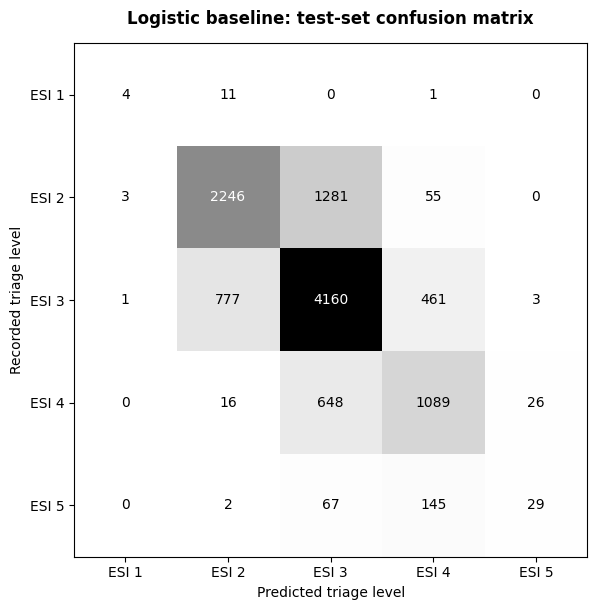

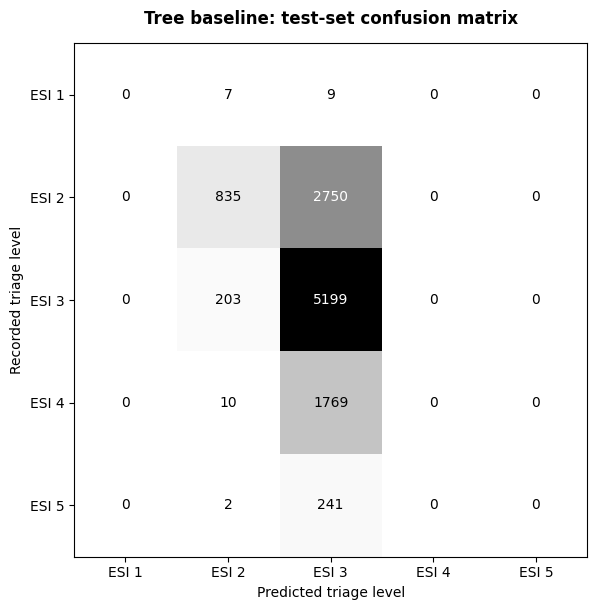

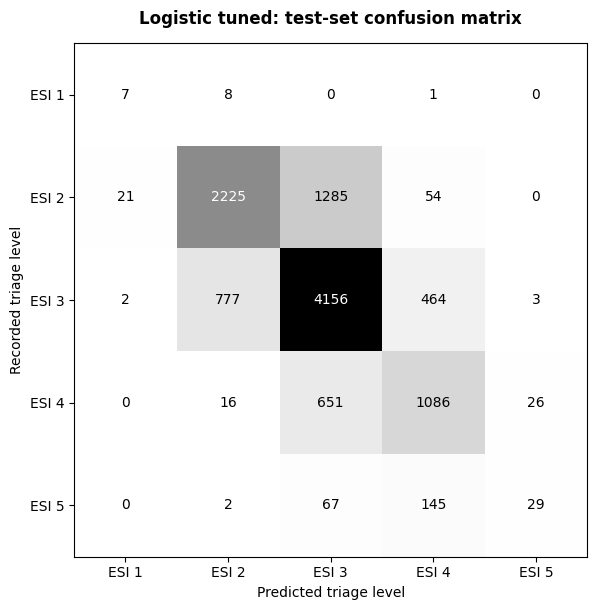

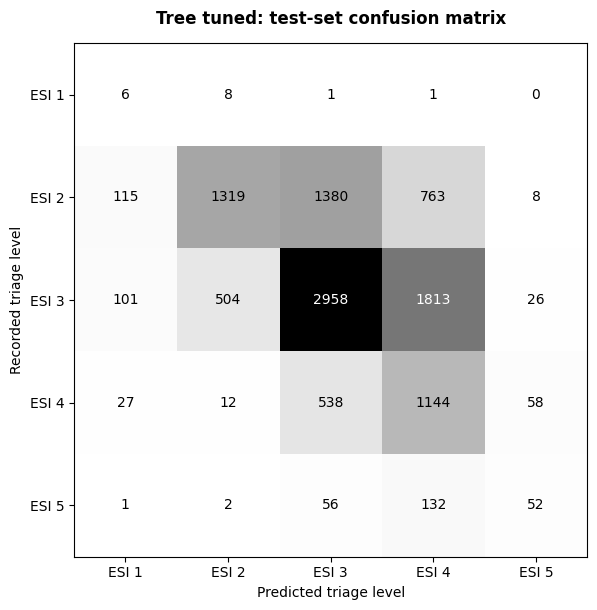

Saved four confusion matrices in docs/.


In [10]:
def save_confusion_matrix(y_pred, title, output_name):
    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=LABELS,
        display_labels=[f"ESI {label}" for label in LABELS],
        cmap="Greys",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(title, pad=14, weight="bold")
    ax.set_xlabel("Predicted triage level")
    ax.set_ylabel("Recorded triage level")
    fig.tight_layout()

    output_path = docs_directory / output_name
    fig.savefig(output_path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    return output_path


matrix_files = {
    "Logistic baseline": "w6_confusion_logreg.png",
    "Tree baseline": "w6_confusion_tree.png",
    "Logistic tuned": "w6_confusion_logreg_tuned.png",
    "Tree tuned": "w6_confusion_tree_tuned.png",
}

for model_name, output_name in matrix_files.items():
    save_confusion_matrix(
        predictions[model_name],
        f"{model_name}: test-set confusion matrix",
        output_name,
    )

print("Saved four confusion matrices in docs/.")

## 10. ESI 1 error review

David recommended looking more closely at the rare ESI 1 cases. I summarise the held-out ESI 1 visits by whether the tuned logistic model caught or missed them. The tables contain aggregate medians and complaint counts only. Multiple complaint flags can appear for one visit, and 16 cases are too few for a clinical conclusion.

In [11]:
tuned_predictions = predictions["Logistic tuned"]
esi_1_mask = (y_test == 1).to_numpy()
esi_1_profile = X_test.loc[y_test == 1].copy()
esi_1_profile["prediction"] = tuned_predictions[esi_1_mask]
esi_1_profile["outcome"] = np.where(esi_1_profile["prediction"] == 1, "caught", "missed")

vital_columns = [
    "age",
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_o2_device",
    "triage_vital_temp",
    "triage_glucose",
]

vital_profile = esi_1_profile.groupby("outcome")[vital_columns].median().T
vital_profile.index.name = "measure"
vital_profile.to_csv(docs_directory / "w6_esi1_vital_profile.csv")

complaint_columns = [column for column in X.columns if column.startswith("cc_")]
complaint_profile = esi_1_profile.groupby("outcome")[complaint_columns].sum().T
complaint_profile["total"] = complaint_profile.sum(axis=1)
complaint_profile = complaint_profile[complaint_profile["total"] > 0].sort_values(
    ["total", "caught"], ascending=False
)
complaint_profile.index = complaint_profile.index.str.replace("cc_", "", regex=False)
complaint_profile.index.name = "complaint flag"
complaint_profile.to_csv(docs_directory / "w6_esi1_complaint_profile.csv")

print(esi_1_profile["outcome"].value_counts().to_string())
vital_profile.round(1).style.format("{:.1f}")

outcome
missed    9
caught    7


outcome,caught,missed
measure,,
age,73.0,81.0
triage_vital_hr,81.0,81.0
triage_vital_sbp,195.5,148.0
triage_vital_dbp,101.0,64.0
triage_vital_rr,18.5,18.0
triage_vital_o2,98.0,96.0
triage_vital_o2_device,1.0,0.0
triage_vital_temp,97.8,97.8
triage_glucose,118.0,113.0


In [12]:
complaint_profile.head(12).style.format("{:.0f}")

outcome,caught,missed,total
complaint flag,,,
strokealert,5,0,5
other,0,4,4
shortnessofbreath,0,2,2
respiratorydistress,1,0,1
unresponsive,1,0,1
alteredmentalstatus,0,1,1
dizziness,0,1,1
hypotension,0,1,1
mass,0,1,1


## 11. Clinical reading

The original logistic model found 4 of 16 ESI 1 visits. The validation-selected class weight raises that to 7 of 16. Accuracy remains close to 68%, but false ESI 1 alerts rise from 4 to 23. That is an improvement in the chosen safety measure, not a general claim that the model is ready.

Five of the seven caught cases carry a stroke-alert flag. The nine misses are more mixed; their flags include shortness of breath, hypotension, altered mental status and several records grouped as other. The missed group is older at the median and has lower median oxygen saturation, but the group is too small to treat those differences as stable evidence.

The balanced tree also catches more ESI 1 cases, but its false-alert count is much higher. I would carry the tuned logistic model forward for calibration and clinician review, not the tuned tree. No version should be deployed from this result.

## 12. Final artefacts

- [Three-page final report](../docs/week-6-baseline.pdf)
- [Clinical explainer video](../docs/week6_clinical_explainer.mp4)
- [Explainer transcript](../docs/week6_clinical_explainer_script.txt)
- docs/w6_final_metrics.csv
- docs/w6_per_class_metrics.csv
- docs/w6_tuning_results.csv
- docs/w6_esi1_vital_profile.csv
- docs/w6_esi1_complaint_profile.csv
- docs/w6_confusion_logreg.png
- docs/w6_confusion_tree.png
- docs/w6_confusion_logreg_tuned.png
- docs/w6_confusion_tree_tuned.png

The full clinical CSV remains local and is excluded from version control.